In [1]:
from dataclasses import dataclass

import pandas as pd 
import numpy as np


In [2]:
filename = "../data/exp21-with-T.csv"
output_name = "exp21withGamma"
output_filename = f"../data/{output_name}.csv"

data = pd.read_csv(filename, delimiter="\t")
data

,№ опыта,"x_вода,%","x_спирт,%","x_гексан,%","y_вода,%","y_спирт,%","y_гексан,%","Σy,%","T кипения, С"
0,1,3.75,15.45,80.80,2.03,15.02,82.95,100.0,56.92
1,2,10.18,33.06,56.76,6.82,17.14,76.04,100.0,56.92
2,3,11.84,47.52,40.64,7.09,15.88,77.03,100.0,56.89
3,4,1.59,38.21,60.20,6.37,14.56,79.08,100.0,57.17
4,5,7.00,49.77,43.22,14.89,26.71,58.40,100.0,62.87
5,6,14.08,51.81,34.11,4.27,17.15,78.58,100.0,56.89
6,7,10.73,11.48,77.80,3.91,14.08,82.01,100.0,57.34
7,8,29.70,5.86,64.44,6.42,7.40,86.19,100.0,59.19
8,9,23.49,71.36,5.15,4.19,95.81,0.00,100.0,78.79
9,10,52.85,42.18,4.97,28.50,71.50,0.00,100.0,83.06


In [3]:
#Вычисление давления насыщенных паров от температуры 

@dataclass(frozen=True)
class AntoinePressure:
    name: str
    t_min: float
    t_max: float
    a: float
    b: float
    c: float
    validate_range: bool = False

    def log10_pressure_bar(self, temperature_k):
        temperature = np.asarray(temperature_k, dtype=float)
        if self.validate_range:
            self._check_temperature_range(temperature)
        log10_pressure = self.a - self.b / (temperature + self.c)
        return self._as_input_type(log10_pressure, temperature_k)

    def pressure_bar(self, temperature_k):
        pressure = 10**self.log10_pressure_bar(temperature_k)
        return self._as_input_type(pressure, temperature_k)

    def pressure_kpa(self, temperature_k):
        pressure = self.pressure_bar(temperature_k) * 100.0
        return self._as_input_type(pressure, temperature_k)

    def pressure_pa(self, temperature_k):
        pressure = self.pressure_bar(temperature_k) * 100000.0
        return self._as_input_type(pressure, temperature_k)

    def _check_temperature_range(self, temperature):
        if np.any((temperature < self.t_min) | (temperature > self.t_max)):
            raise ValueError(
                f"{self.name}: temperature must be in "
                f"[{self.t_min}, {self.t_max}] K"
            )

    @staticmethod
    def _as_input_type(value, original_input):
        if np.isscalar(original_input):
            return float(value)
        return value


class WaterPressure(AntoinePressure):
    def __init__(self):
        super().__init__(
            name="water",
            t_min=255.9,
            t_max=373.0,
            a=4.6543,
            b=1435.264,
            c=-64.848,
        )


class EthanolPressure(AntoinePressure):
    def __init__(self):
        super().__init__(
            name="ethanol",
            t_min=292.77,
            t_max=366.63,
            a=5.24677,
            b=1598.673,
            c=-46.424,
        )


class NHexanePressure(AntoinePressure):
    def __init__(self):
        super().__init__(
            name="n-hexane",
            t_min=286.18,
            t_max=342.69,
            a=4.00266,
            b=1171.53,
            c=-48.784,
        )


In [4]:
# Молярные массы, г/моль: H2O, EtOH, н-гексан
MOLAR_MASSES = np.array([18.0, 46.0, 86.0])
X_MASS_PERCENT_COLS = ["x_вода,%", "x_спирт,%", "x_гексан,%"]
Y_MASS_PERCENT_COLS = ["y_вода,%", "y_спирт,%", "y_гексан,%"]
X_MOL_COLS = ["x1_mol", "x2_mol", "x3_mol"]
Y_MOL_COLS = ["y1_mol", "y2_mol", "y3_mol"]


def _mass_percent_row_to_mole_fraction(values):
    mass_percent = np.asarray(values, dtype=float)
    moles = mass_percent / MOLAR_MASSES
    total_moles = moles.sum()

    if total_moles <= 0 or np.isnan(total_moles):
        return np.full_like(moles, np.nan, dtype=float)

    return moles / total_moles


def AddMoleFractions(data):
    data = data.copy()
    x_mol = np.array(
        [
            _mass_percent_row_to_mole_fraction(row[X_MASS_PERCENT_COLS])
            for _, row in data.iterrows()
        ]
    )
    y_mol = np.array(
        [
            _mass_percent_row_to_mole_fraction(row[Y_MASS_PERCENT_COLS])
            for _, row in data.iterrows()
        ]
    )

    data[X_MOL_COLS] = x_mol
    data[Y_MOL_COLS] = y_mol
    return data


data_mol = AddMoleFractions(data)


def CalculateGamma(data):
    P = 101325.0
    pressure_models = {
        "water": WaterPressure(),
        "ethanol": EthanolPressure(),
        "hexane": NHexanePressure(),
    }
    gamma_rows = []

    for _, row in data.iterrows():
        temperature_k = row["T кипения, С"] + 273.15
        gamma_rows.append(
            {
                "n": int(row["№ опыта"]),
                "T,K": temperature_k,
                "p1": pressure_models["water"].pressure_pa(temperature_k),
                "p2": pressure_models["ethanol"].pressure_pa(temperature_k),
                "p3": pressure_models["hexane"].pressure_pa(temperature_k),
                "gamma_water": _gamma(
                    P,
                    pressure_models["water"],
                    temperature_k,
                    row["y1_mol"],
                    row["x1_mol"],
                ),
                "gamma_ethanol": _gamma(
                    P,
                    pressure_models["ethanol"],
                    temperature_k,
                    row["y2_mol"],
                    row["x2_mol"],
                ),
                "gamma_hexane": _gamma(
                    P,
                    pressure_models["hexane"],
                    temperature_k,
                    row["y3_mol"],
                    row["x3_mol"],
                ),
            }
        )

    return pd.DataFrame(gamma_rows)


def _gamma(P, pressure_model, temperature_k, y_mol, x_mol):
    if x_mol == 0:
        return np.nan
    if y_mol == 0:
        return 0.0

    return y_mol * P / (x_mol * pressure_model.pressure_pa(temperature_k))


gamma_df = CalculateGamma(data_mol)

result_df = pd.DataFrame(
    {
        "T": data_mol["T кипения, С"],
        "x1": data_mol["x1_mol"].round(5),
        "x2": data_mol["x2_mol"].round(5),
        "x3": data_mol["x3_mol"].round(5),
        "y1": data_mol["y1_mol"].round(5),
        "y2": data_mol["y2_mol"].round(5),
        "y3": data_mol["y3_mol"].round(5),
        "p1": gamma_df["p1"].round(2),
        "p2": gamma_df["p2"].round(2),
        "p3": gamma_df["p3"].round(2),
        "gamma1": gamma_df["gamma_water"].round(3),
        "gamma2": gamma_df["gamma_ethanol"].round(3),
        "gamma3": gamma_df["gamma_hexane"].round(3),
    }
)
result_df.to_csv(output_filename, sep="\t", index=False)

result_df

,T,x1,x2,x3,y1,y2,y3,p1,p2,p3,gamma1,gamma2,gamma3
0,56.92,0.14041,0.22637,0.63322,0.08034,0.23259,0.68707,17488.11,40795.70,68826.09,3.315,2.552,1.597
1,56.92,0.29089,0.36965,0.33946,0.23164,0.22780,0.54056,17488.11,40795.70,68826.09,4.614,1.531,2.344
2,56.89,0.30405,0.47751,0.21844,0.24094,0.21117,0.54789,17463.48,40739.73,68755.72,4.598,1.100,3.696
3,57.17,0.05456,0.51307,0.43237,0.22258,0.19908,0.57834,17694.53,41264.60,69414.71,23.360,0.953,1.953
4,62.87,0.19707,0.54827,0.25467,0.39638,0.27823,0.32539,22986.99,53261.58,83951.37,8.866,0.965,1.542
5,56.89,0.33934,0.48860,0.17206,0.15568,0.24467,0.59965,17463.48,40739.73,68755.72,2.662,1.245,5.136
6,57.34,0.34057,0.14258,0.51685,0.14708,0.20725,0.64567,17836.06,41586.04,69817.23,2.453,3.542,1.813
7,59.19,0.65303,0.05042,0.29655,0.23469,0.10585,0.65946,19438.67,45223.28,74318.20,1.873,4.704,3.032
8,78.79,0.44750,0.53196,0.02053,0.10053,0.89947,0.00000,45183.80,103293.23,137471.91,0.504,1.659,0.000
9,83.06,0.75076,0.23446,0.01478,0.50462,0.49538,0.00000,53487.12,121954.51,155556.90,1.273,1.755,0.000


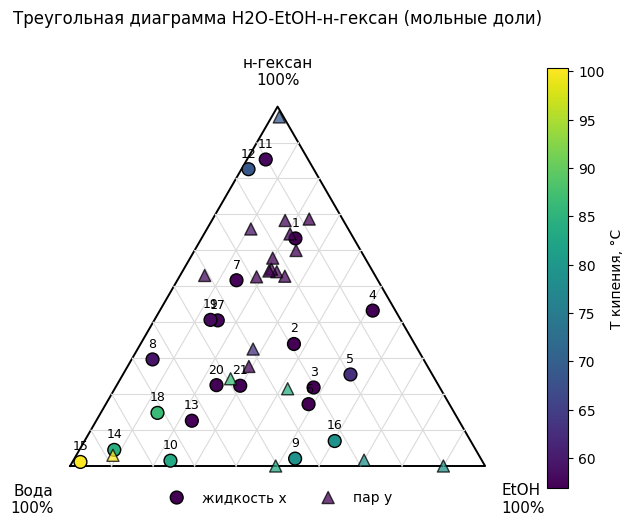

In [5]:
import matplotlib.pyplot as plt


def _ternary_xy(water, ethanol, hexane):
    water = np.asarray(water, dtype=float)
    ethanol = np.asarray(ethanol, dtype=float)
    hexane = np.asarray(hexane, dtype=float)
    total = water + ethanol + hexane

    water = water / total
    ethanol = ethanol / total
    hexane = hexane / total

    x = ethanol + 0.5 * hexane
    y = np.sqrt(3) / 2 * hexane
    return x, y


def _draw_ternary_grid(ax):
    height = np.sqrt(3) / 2
    triangle_x = [0, 1, 0.5, 0]
    triangle_y = [0, 0, height, 0]
    ax.plot(triangle_x, triangle_y, color="black", linewidth=1.4)

    for percent in range(10, 100, 10):
        part = percent / 100
        ax.plot([1 - part, 0.5 * (1 - part)], [0, height * (1 - part)], color="0.86", linewidth=0.8)
        ax.plot([part, 0.5 + 0.5 * part], [0, height * (1 - part)], color="0.86", linewidth=0.8)
        ax.plot([0.5 * part, 1 - 0.5 * part], [height * part, height * part], color="0.86", linewidth=0.8)

    ax.text(-0.04, -0.04, "Вода\n100%", ha="right", va="top", fontsize=11)
    ax.text(1.04, -0.04, "EtOH\n100%", ha="left", va="top", fontsize=11)
    ax.text(0.5, height + 0.045, "н-гексан\n100%", ha="center", va="bottom", fontsize=11)

    ax.set_aspect("equal")
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.10, height + 0.14)
    ax.axis("off")


def PlotTernaryDiagram(data, show_vapor=True):
    if "T кипения, С" not in data.columns:
        data = pd.read_csv(filename, delimiter="\t")
    plot_data = AddMoleFractions(data)

    fig, ax = plt.subplots(figsize=(8, 7))
    _draw_ternary_grid(ax)

    liquid_x, liquid_y = _ternary_xy(
        plot_data["x1_mol"],
        plot_data["x2_mol"],
        plot_data["x3_mol"],
    )
    colors = plot_data["T кипения, С"]
    liquid_points = ax.scatter(
        liquid_x,
        liquid_y,
        c=colors,
        cmap="viridis",
        s=85,
        edgecolors="black",
        marker="o",
        label="жидкость x",
        zorder=3,
    )

    if show_vapor:
        vapor_x, vapor_y = _ternary_xy(
            plot_data["y1_mol"],
            plot_data["y2_mol"],
            plot_data["y3_mol"],
        )
        ax.scatter(
            vapor_x,
            vapor_y,
            c=colors,
            cmap="viridis",
            s=75,
            edgecolors="black",
            marker="^",
            label="пар y",
            alpha=0.75,
            zorder=3,
        )

    for (_, row), x, y in zip(plot_data.iterrows(), liquid_x, liquid_y):
        ax.text(x, y + 0.022, str(int(row["№ опыта"])), ha="center", va="bottom", fontsize=9)

    colorbar = fig.colorbar(liquid_points, ax=ax, shrink=0.78, pad=0.02)
    colorbar.set_label("T кипения, °C")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
    ax.set_title("Треугольная диаграмма H2O-EtOH-н-гексан (мольные доли)", pad=18)
    return fig, ax


fig, ax = PlotTernaryDiagram(data)
plt.show()